# Diagnosing Multiple Sclerosis from MRI Scans using ResNet18

This notebook demonstrates how to build a deep learning model for classifying MRI images as Multiple Sclerosis (MS) or Control using ResNet18 as a backbone with a custom classification head.

## 1. Import Required Libraries

We will use PyTorch and torchvision for model implementation, along with libraries for data handling, image processing, and visualization.

In [1]:
# Data handling and visualization
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Utility
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# For Kaggle dataset download
import kagglehub

## 2. Download and Prepare MRI Dataset

Download the MRI dataset from Kaggle using kagglehub, set up the directory structure, and verify available categories.

In [2]:
# Set custom download directory
os.environ["KAGGLEHUB_CACHE"] = "../../data/raw"

# Download dataset if not already present
if not os.listdir("../../data/raw"):
    path = kagglehub.dataset_download("buraktaci/multiple-sclerosis")
    print("Dataset downloaded to:", path)
else:
    print("Dataset already exists in ../../data/raw")
    path = "../../data/raw/datasets/buraktaci/multiple-sclerosis/versions/1/MS/"

# List available categories
categories = os.listdir(path)
print("Available categories:", categories)

Dataset already exists in ../../data/raw
Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']


## 3. Visualize Sample MRI Images

Display random samples of control and MS MRI images for visual inspection.

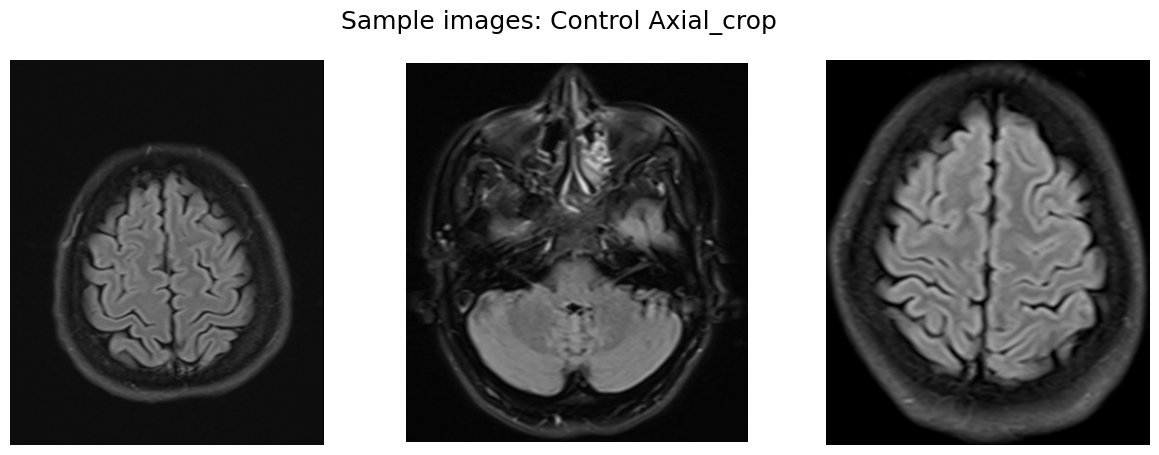

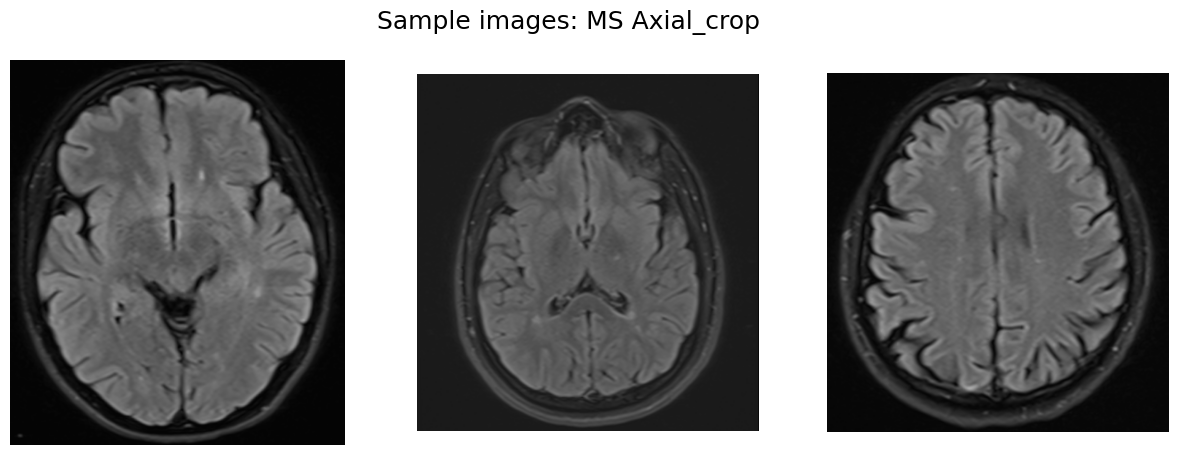

In [ ]:
# Define image categories
control_axial = "Control Axial_crop"
ms_axial = "MS Axial_crop"

control_sagittal = "Control Sagittal_crop"
ms_sagittal = "MS Sagittal_crop"

classes = [control_axial, ms_axial]

# Visualize 3 random images from each category
for cat in classes:
    image_dir = os.path.join(path, cat)
    images = os.listdir(image_dir)
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Sample images: {cat}', fontsize=18)
    for i in range(3):
        idx = np.random.randint(0, len(images))
        img = np.array(Image.open(os.path.join(image_dir, images[idx])))
        ax[i].imshow(img, cmap='gray')
        ax[i].axis('off')
    plt.show()

## 4. Preprocess MRI Images

Resize images to 224x224, normalize pixel values, encode labels, and optionally augment data. Prepare PyTorch datasets and dataloaders.

In [4]:
IMG_SIZE = (224, 224)

class MRIDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label

# Gather image paths and labels
image_paths = []
labels = []
for label, cat in enumerate(classes):
    image_dir = os.path.join(path, cat)
    for fname in os.listdir(image_dir):
        img_path = os.path.join(image_dir, fname)
        image_paths.append(img_path)
        labels.append(label)

print(f"Total images: {len(image_paths)}")

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Total images: 1652


## 5. Split Data into Train and Test Sets

Split the dataset into training and testing sets using sklearn's train_test_split. Prepare corresponding dataloaders.

In [5]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# Create datasets
train_dataset = MRIDataset(X_train, y_train, transform=train_transform)
test_dataset = MRIDataset(X_test, y_test, transform=test_transform)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Training samples: 1321, Testing samples: 331


## 6. Load ResNet18 Backbone and Remove Head

Load a pretrained ResNet18 model from torchvision, remove its classification head (fc layer), and freeze backbone weights if desired.

In [6]:
# Load pretrained ResNet18
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Remove the classification head (fc layer)
num_features = resnet18.fc.in_features
resnet18.fc = nn.Identity()

# Optionally freeze backbone weights
for param in resnet18.parameters():
    param.requires_grad = False

print(resnet18)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\markm/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:05<00:00, 8.97MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 7. Build Custom Classification Head

Attach a new classification head suitable for binary classification (MS vs Control) to the ResNet18 backbone.

In [7]:
class MSResNet18(nn.Module):
    def __init__(self, backbone, num_features):
        super(MSResNet18, self).__init__()
        self.backbone = backbone
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

model = MSResNet18(resnet18, num_features)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(model)

MSResNet18(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

## 8. Train the Model

Train the modified ResNet18 model on the training data, monitor loss and accuracy, and use validation data for early stopping.

In [8]:
# Training setup
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
num_epochs = 15

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = torch.tensor(labels, dtype=torch.float32).to(device)
        labels = labels.unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.sigmoid(outputs).detach().cpu().numpy() > 0.5
        correct += (preds == labels.cpu().numpy()).sum()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f}")

C:\Users\markm\AppData\Local\Temp\ipykernel_27776\280720107.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float32).to(device)


Epoch 1/15 - Loss: 0.5291 - Acc: 0.7290
Epoch 2/15 - Loss: 0.4388 - Acc: 0.7971
Epoch 3/15 - Loss: 0.3946 - Acc: 0.8206
Epoch 4/15 - Loss: 0.3549 - Acc: 0.8312
Epoch 5/15 - Loss: 0.3610 - Acc: 0.8350
Epoch 6/15 - Loss: 0.3927 - Acc: 0.8221
Epoch 7/15 - Loss: 0.3330 - Acc: 0.8653
Epoch 8/15 - Loss: 0.3596 - Acc: 0.8335
Epoch 9/15 - Loss: 0.3290 - Acc: 0.8600
Epoch 10/15 - Loss: 0.3170 - Acc: 0.8645
Epoch 11/15 - Loss: 0.3083 - Acc: 0.8653
Epoch 12/15 - Loss: 0.3163 - Acc: 0.8660
Epoch 13/15 - Loss: 0.3174 - Acc: 0.8584
Epoch 14/15 - Loss: 0.2985 - Acc: 0.8660
Epoch 15/15 - Loss: 0.2879 - Acc: 0.8751


## 9. Evaluate Model Performance

Assess the model's accuracy, precision, recall, confusion matrix, and classification report on the test set.

In [9]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = torch.tensor(labels, dtype=torch.float32).to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)
        y_true.extend(labels.cpu().numpy().astype(int))
        y_pred.extend(preds)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred))

C:\Users\markm\AppData\Local\Temp\ipykernel_27776\4256179629.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float32).to(device)


Accuracy: 0.8549848942598187
Precision: 0.8203125
Recall: 0.8076923076923077
Confusion Matrix:
 [[178  23]
 [ 25 105]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.88       201
           1       0.82      0.81      0.81       130

    accuracy                           0.85       331
   macro avg       0.85      0.85      0.85       331
weighted avg       0.85      0.85      0.85       331



## 10. Make Predictions on Test Images

Use the trained model to predict MS/control on unseen MRI images and visualize the results with matplotlib.

In [1]:
# Visualize predictions on random test images
num_samples = 10
indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

model.eval()
for i, idx in enumerate(indices):
    img_path = X_test[idx]
    img = Image.open(img_path).convert('RGB')
    img_tensor = test_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        prob = torch.sigmoid(output).item()
        pred_label = "MS" if prob > 0.5 else "Control"
    true_label = "MS" if y_test[idx] == 1 else "Control"
    row = i // 5
    col = i % 5
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f"Actual: {true_label}\nPred: {pred_label}", fontsize=11)
    axes[row, col].axis('off')
plt.suptitle("Model Predictions on Test Images", fontsize=18)
plt.show()

NameError: name 'np' is not defined